importing libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import sklearn
import sklearn.datasets
import sklearn.linear_model
import seaborn as sns

%matplotlib inline

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/exercise.csv')

In [ ]:
df.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,male,68,190,94,29,105,40.8,231
1,14861698,female,20,166,60,14,94,40.3,66
2,11179863,male,69,179,79,5,88,38.7,26
3,16180408,female,34,179,71,13,100,40.5,71
4,17771927,female,27,154,58,10,81,39.8,35


In [ ]:
# no need of User_ID column
df.drop('User_ID', axis=1, inplace=True)

In [ ]:
df.shape

(15000, 8)

In [ ]:
df.columns.unique()

Index(['Gender', 'Age', 'Height', 'Weight', 'Duration', 'Heart_Rate',
       'Body_Temp', 'Calories'],
      dtype='object')

In [ ]:
df.isnull().sum()

,0
Gender,0
Age,0
Height,0
Weight,0
Duration,0
Heart_Rate,0
Body_Temp,0
Calories,0


Since there are no missing values , we can proceed with our analysis

In [ ]:
df.describe()

,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,42.789800,174.465133,74.966867,15.530600,95.518533,40.025453,89.539533
std,16.980264,14.258114,15.035657,8.319203,9.583328,0.779230,62.456978
min,20.000000,123.000000,36.000000,1.000000,67.000000,37.100000,1.000000
25%,28.000000,164.000000,63.000000,8.000000,88.000000,39.600000,35.000000
50%,39.000000,175.000000,74.000000,16.000000,96.000000,40.200000,79.000000
75%,56.000000,185.000000,87.000000,23.000000,103.000000,40.600000,138.000000
max,79.000000,222.000000,132.000000,30.000000,128.000000,41.500000,314.000000


In [ ]:
df['Gender'].value_counts()

,count
Gender,
female,7553
male,7447


<Axes: xlabel='count', ylabel='Gender'>

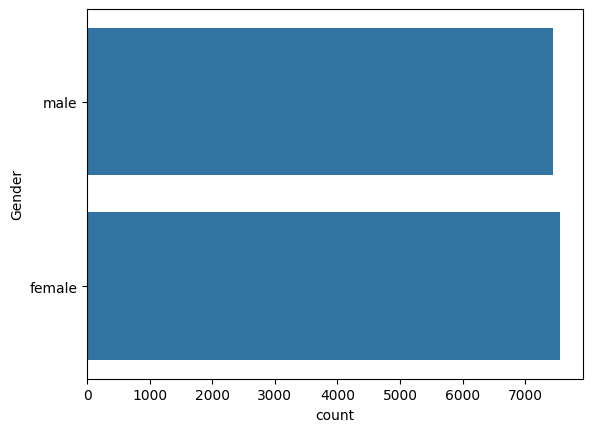

In [ ]:
# create a count plot
sns.countplot(df['Gender'])

In [ ]:
# Convert Gender to binary: Male = 1, Female = 0
df['Gender'] = df['Gender'].map({'male': 1, 'female': 0})

In [ ]:
df["Gender"]

,Gender
0,1
1,0
2,1
3,0
4,0
...,...
14995,0
14996,0
14997,0
14998,1


In [ ]:
correlation_matrix = df.corr()

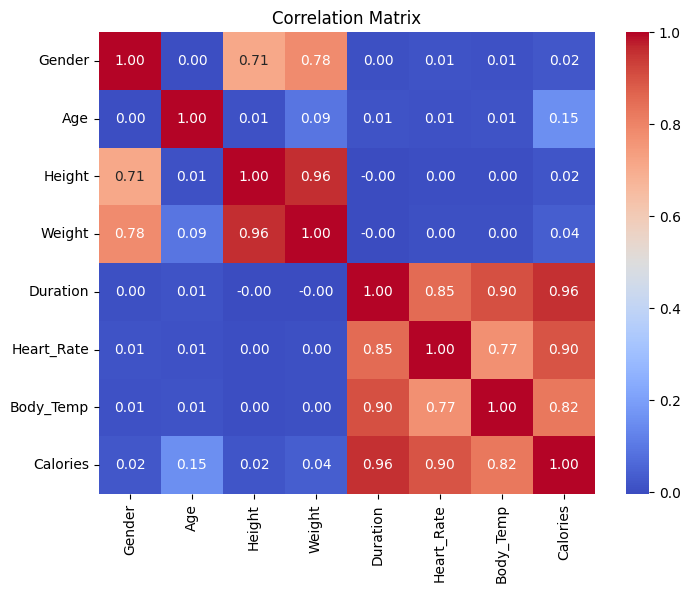

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

# Histogram of certain columns:

array([[<Axes: title={'center': 'Gender'}>,
        <Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Height'}>],
       [<Axes: title={'center': 'Weight'}>,
        <Axes: title={'center': 'Duration'}>,
        <Axes: title={'center': 'Heart_Rate'}>],
       [<Axes: title={'center': 'Body_Temp'}>,
        <Axes: title={'center': 'Calories'}>, <Axes: >]], dtype=object)

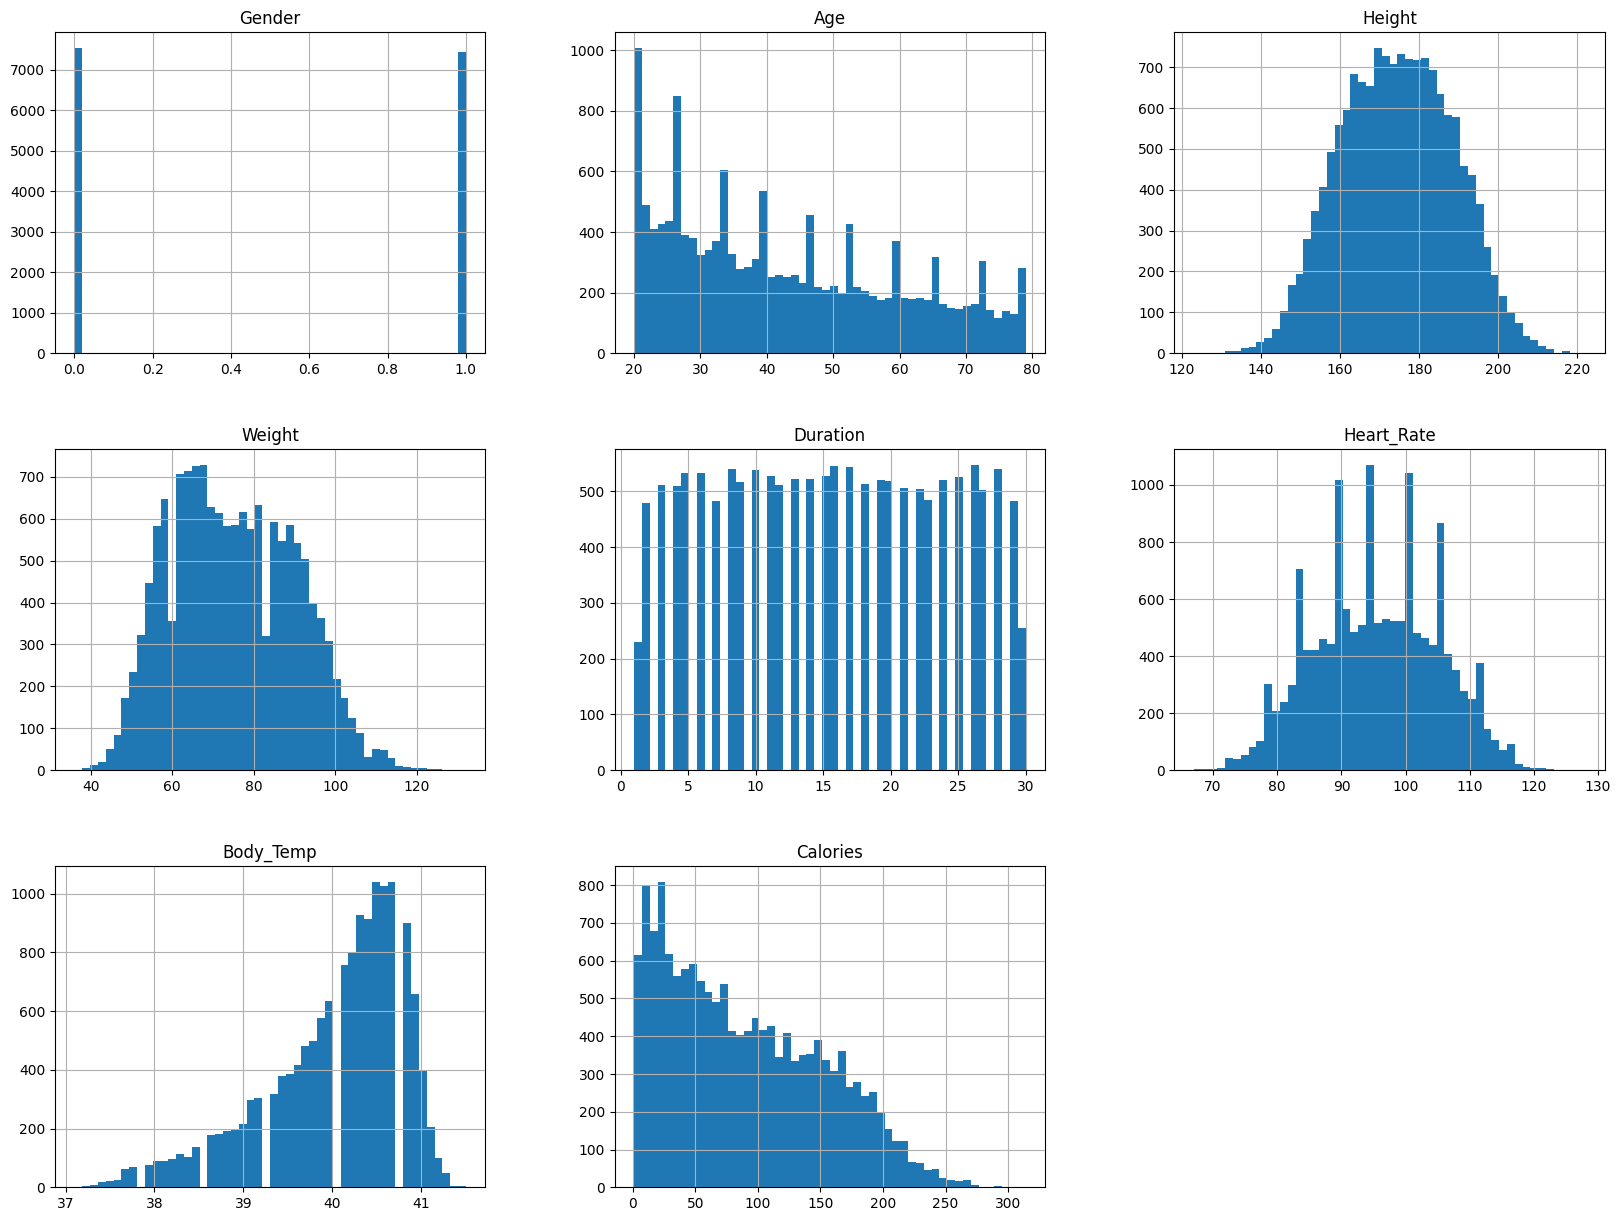

In [ ]:
df.hist(bins=50, figsize=(20,15))

# Boxplot of certain columns

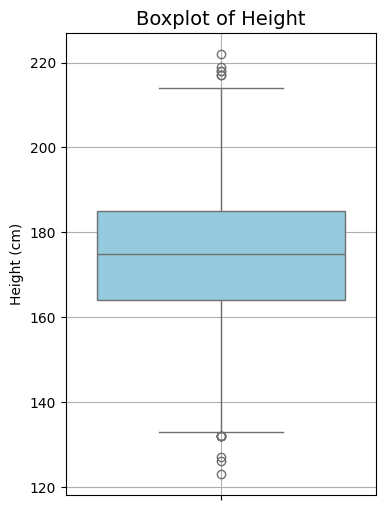

In [ ]:
plt.figure(figsize=(4, 6))
sns.boxplot(y = df['Height'], color='skyblue')  # y because it's a vertical boxplot

plt.title("Boxplot of Height", fontsize=14)
plt.ylabel("Height (cm)")
plt.grid(True)
plt.show()

/tmp/ipython-input-114-2715821604.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Column', y='Value', data=df_melted, palette='Set3')


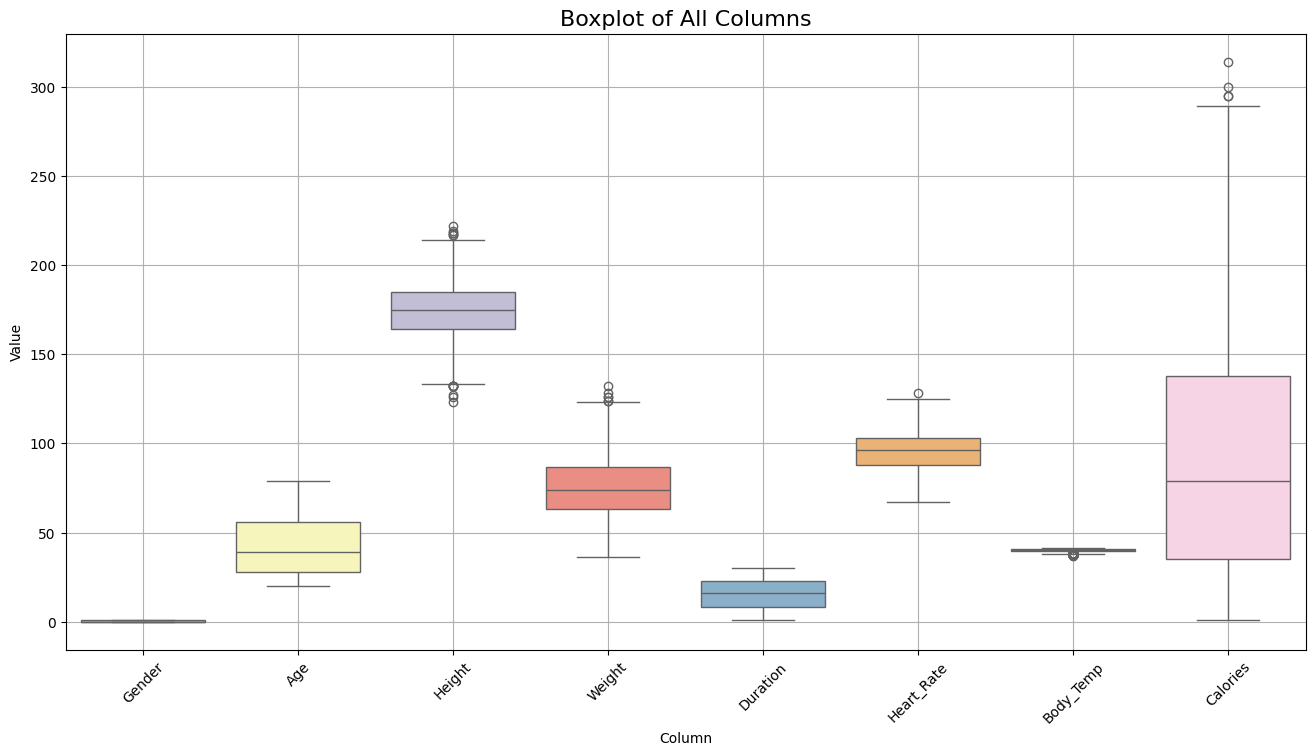

In [ ]:
df_melted = df.melt(var_name='Column', value_name='Value')

plt.figure(figsize=(16, 8))
sns.boxplot(x='Column', y='Value', data=df_melted, palette='Set3')

plt.title('Boxplot of All Columns', fontsize=16)
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

Fix outlier for Height

In [ ]:
def get_outliers(df, column_name, verbose=True):
    data = df[column_name]
    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outliers = data[(data < lower_bound) | (data > upper_bound)]

    if verbose:
        print(f"Outliers found in '{column_name}': {len(outliers)}")

    return outliers

In [ ]:
get_outliers(df, 'Height', verbose=True)

Outliers found in 'Height': 14


,Height
529,132
1464,217
4200,123
4404,132
4855,132
6226,127
6711,218
7774,126
8931,132
10362,222


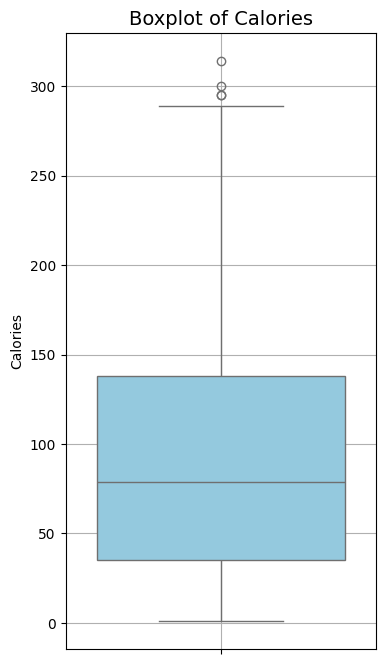

In [ ]:
plt.figure(figsize=(4, 8))
sns.boxplot(y = df['Calories'], color='skyblue')  # y because it's a vertical boxplot

plt.title("Boxplot of Calories", fontsize=14)
plt.ylabel("Calories")
plt.grid(True)
plt.show()

#OUTLIERS FOR WEIGHT

In [ ]:
get_outliers(df, 'Weight', verbose=True)

Outliers found in 'Weight': 6


,Weight
1909,124
6711,132
10362,128
12189,126
13276,126
13806,124


In [ ]:
get_outliers(df, 'Heart_Rate', verbose=True)

Outliers found in 'Heart_Rate': 1


,Heart_Rate
9981,128


In [ ]:
df.head()

,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,1,68,190,94,29,105,40.8,231
1,0,20,166,60,14,94,40.3,66
2,1,69,179,79,5,88,38.7,26
3,0,34,179,71,13,100,40.5,71
4,0,27,154,58,10,81,39.8,35


#OUTLIERS FOR Body Temperature

In [ ]:
get_outliers(df, 'Body_Temp', verbose=True)

Outliers found in 'Body_Temp': 369


,Body_Temp
10,37.8
24,37.7
49,38.0
232,37.9
301,37.6
...,...
14732,37.9
14749,37.9
14753,38.0
14894,38.0


#OUTLIERS FOR CALORIES

In [ ]:
get_outliers(df, 'Calories', verbose=True)

Outliers found in 'Calories': 4


,Calories
428,314
3357,295
6240,300
13871,295


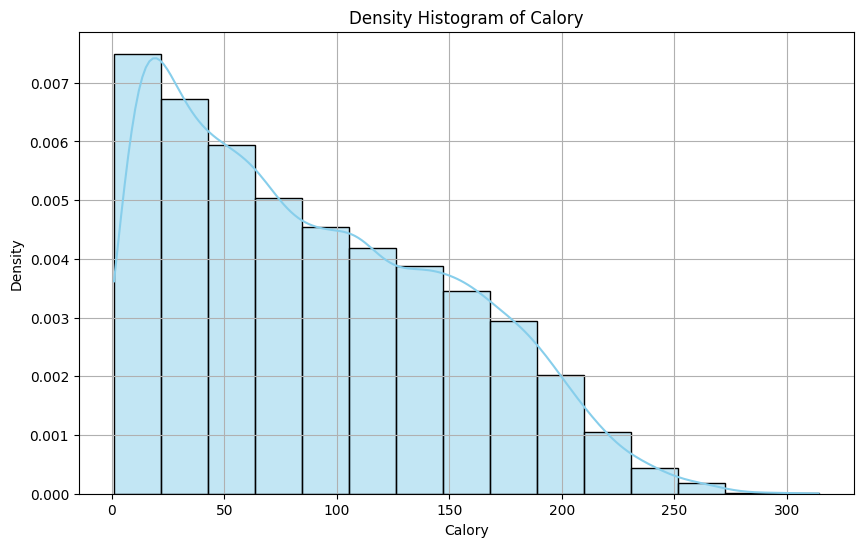

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Calories'], kde=True, stat="density", bins=15, color='skyblue')

plt.title('Density Histogram of Calory')
plt.xlabel('Calory')
plt.ylabel('Density')
plt.grid(True)
plt.show()

*The data of Calories is positively skewed *

**Boxplot of Calories**

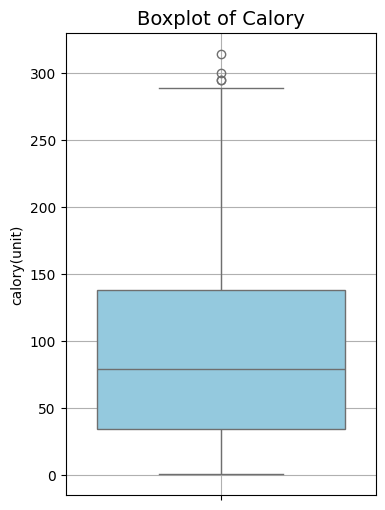

In [ ]:
plt.figure(figsize=(4, 6))
sns.boxplot(y = df['Calories'], color='skyblue')  # y because it's a vertical boxplot

plt.title("Boxplot of Calory", fontsize=14)
plt.ylabel("calory(unit)")
plt.grid(True)
plt.show()

Normality: Use the hist() function to test whether our dependent variable follows a normal
distribution HEIGHT

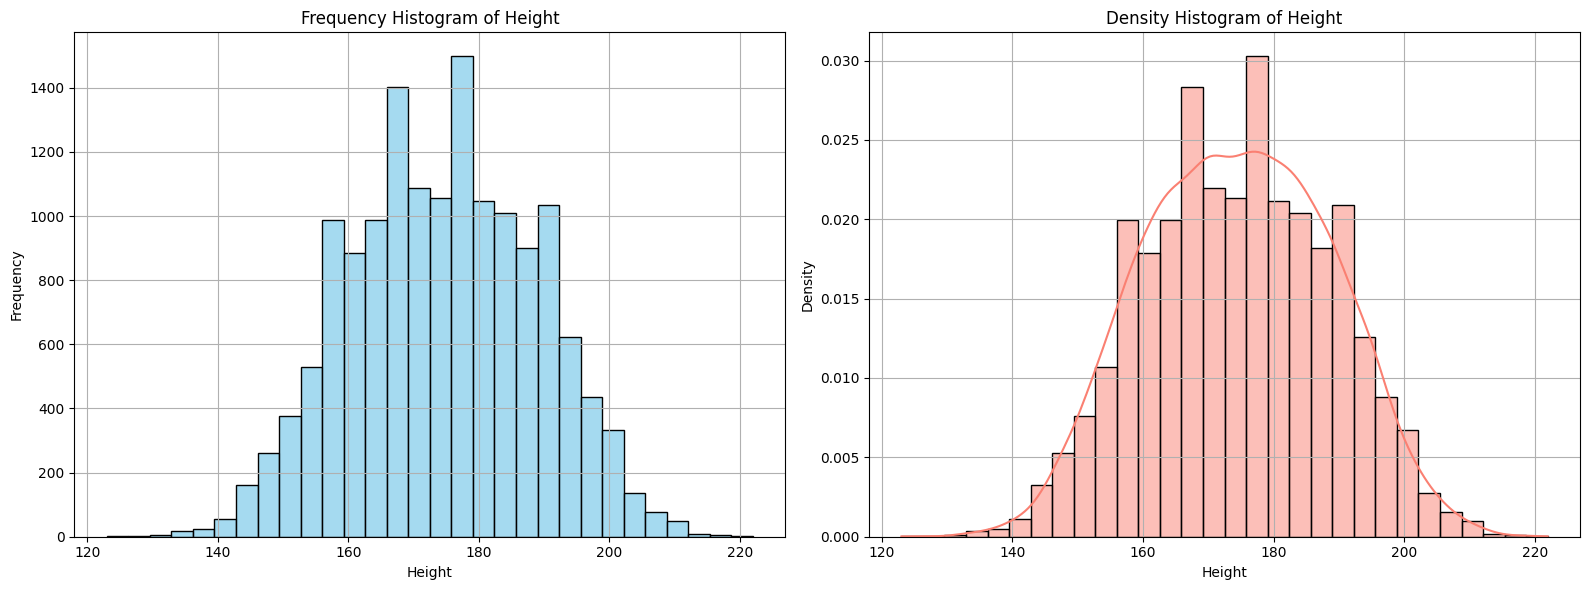

In [ ]:
# Set up subplots: 1 row, 2 columns
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Frequency histogram
sns.histplot(df['Height'], bins=30, kde=False, color='skyblue', ax=axes[0])
axes[0].set_title("Frequency Histogram of Height")
axes[0].set_xlabel("Height")
axes[0].set_ylabel("Frequency")
axes[0].grid(True)

# Density histogram
sns.histplot(df['Height'], bins=30, kde=True, stat="density", color='salmon', ax=axes[1])
axes[1].set_title("Density Histogram of Height")
axes[1].set_xlabel("Height")
axes[1].set_ylabel("Density")
axes[1].grid(True)

# Adjust layout
plt.tight_layout()
plt.show()

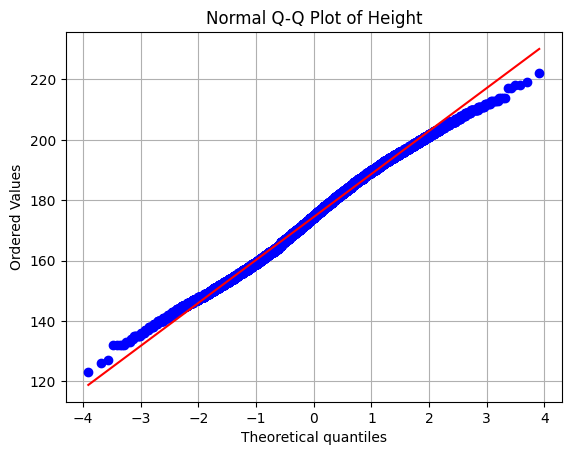

In [ ]:

import scipy.stats as stats

stats.probplot(df['Height'], dist="norm", plot=plt)
plt.title("Normal Q-Q Plot of Height")
plt.grid(True)
plt.show()

*Linearity:We can check this by using scatterplot between Calories and Height*

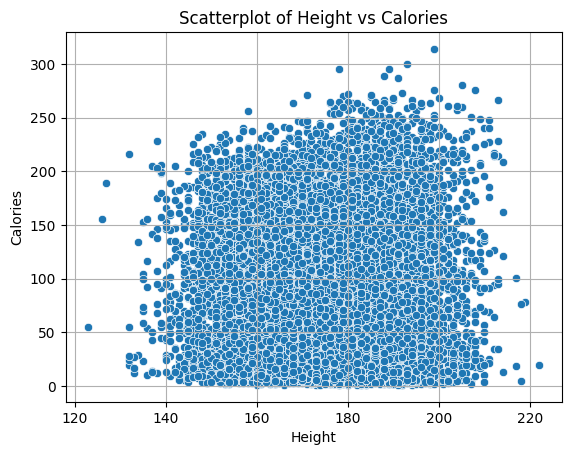

In [ ]:
sns.scatterplot(x='Height', y='Calories', data=df)

plt.title("Scatterplot of Height vs Calories")
plt.xlabel("Height")
plt.ylabel("Calories")
plt.grid(True)
plt.show()

/tmp/ipython-input-128-2653612386.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  height_bar = df.groupby('Height_Group')['Calories'].mean().reset_index()
/tmp/ipython-input-128-2653612386.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Height_Group', y='Calories', data=height_bar, palette='viridis')


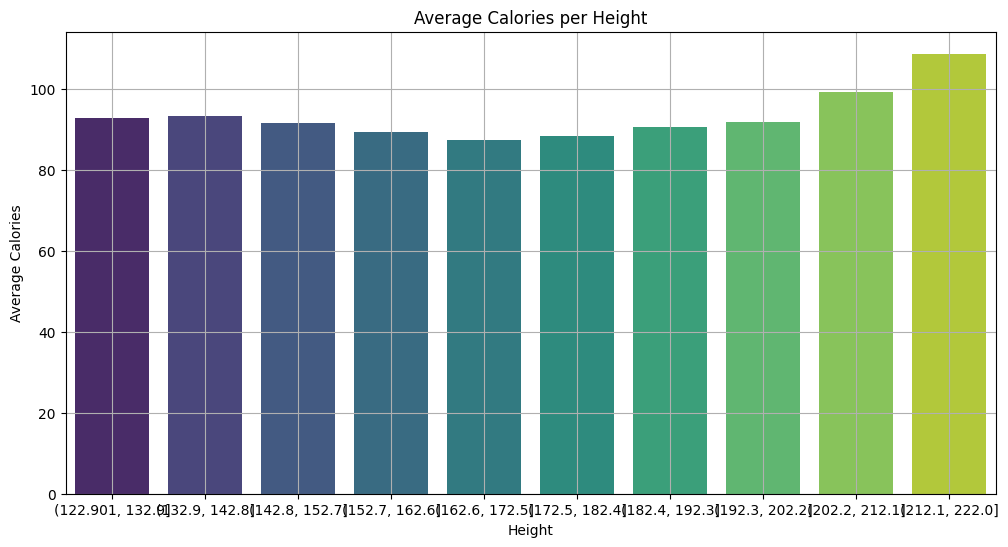

In [ ]:
# Bin height into groups
df['Height_Group'] = pd.cut(df['Height'], bins=10)

height_bar = df.groupby('Height_Group')['Calories'].mean().reset_index()
avg_calories = df.groupby('Height')['Calories'].mean().reset_index()

# Line plot
plt.figure(figsize=(12, 6))
sns.barplot(x='Height_Group', y='Calories', data=height_bar, palette='viridis')

plt.title("Average Calories per Height")
plt.xlabel("Height")
plt.ylabel("Average Calories")
plt.grid(True)
plt.show()

# Fitting a linear model between Calories vs Height

In [ ]:
# Reshape X for sklearn (expects 2D array)
X = df[['Height']]     # independent variable
y = df['Calories']       # dependent variable
model = LinearRegression()
model.fit(X, y)


LinearRegression()

In [ ]:
y_pred = model.predict(X)

# Calculate R² and RMSE
r2 = r2_score(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))

print("Intercept:", model.intercept_)
print("Slope:", model.coef_[0])
print("R² Score:", r2)
print("RMSE:", rmse)


Intercept: 76.13730243918396
Slope: 0.07681896455805334
R² Score: 0.0003075382274944083
RMSE: 62.44529164947859


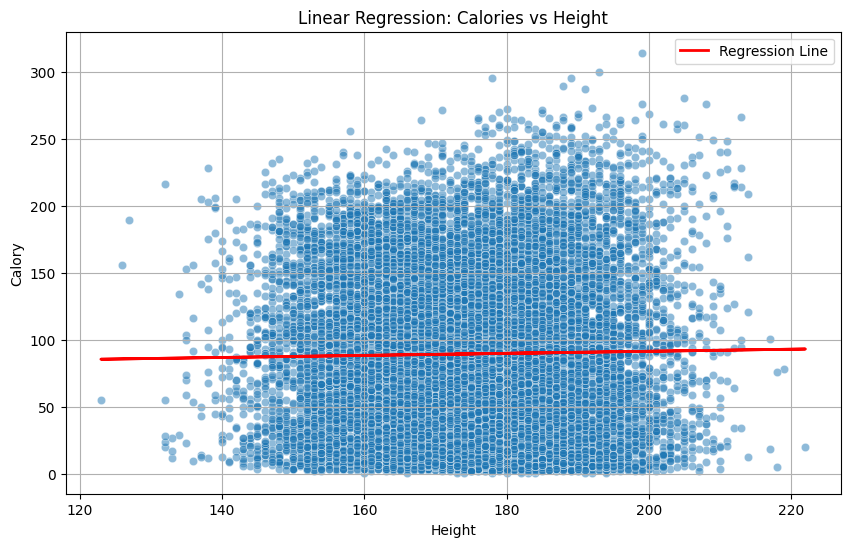

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Height', y='Calories', data=df, alpha=0.5)
plt.plot(df['Height'], y_pred, color='red', linewidth=2, label='Regression Line')

plt.title("Linear Regression: Calories vs Height")
plt.xlabel("Height")
plt.ylabel("Calory")
plt.legend()
plt.grid(True)
plt.show()


Check for homoscedasticity:

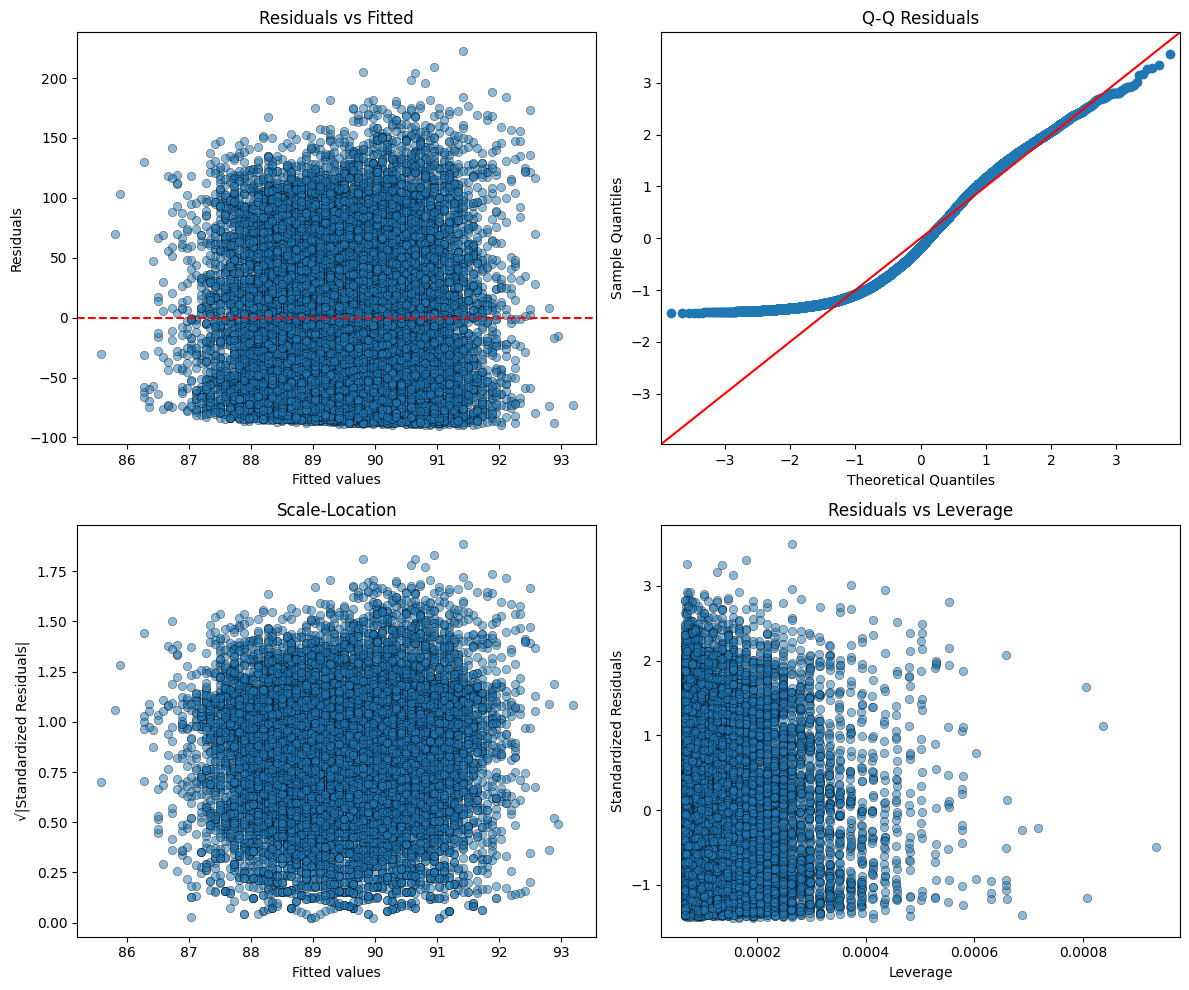

In [ ]:
import statsmodels.api as sm
# Prepare data
X = df['Height']
y = df['Calories']
X_const = sm.add_constant(X)  # Adds intercept term

# Fit OLS model
model = sm.OLS(y, X_const).fit()

# Extract diagnostics
fitted_vals = model.fittedvalues
residuals = model.resid
standardized_resid = residuals / np.std(residuals)
sqrt_std_resid = np.sqrt(np.abs(standardized_resid))
influence = model.get_influence()
leverage = influence.hat_matrix_diag

# Set up 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. Residuals vs Fitted
sns.scatterplot(x=fitted_vals, y=residuals, ax=axes[0, 0], edgecolor='k', alpha=0.5)
axes[0, 0].axhline(0, ls='--', color='red')
axes[0, 0].set_title("Residuals vs Fitted")
axes[0, 0].set_xlabel("Fitted values")
axes[0, 0].set_ylabel("Residuals")

# 2. Q-Q Plot
sm.qqplot(standardized_resid, line='45', ax=axes[0, 1])
axes[0, 1].set_title("Q-Q Residuals")

# 3. Scale-Location
sns.scatterplot(x=fitted_vals, y=sqrt_std_resid, ax=axes[1, 0], edgecolor='k', alpha=0.5)
axes[1, 0].set_title("Scale-Location")
axes[1, 0].set_xlabel("Fitted values")
axes[1, 0].set_ylabel("√|Standardized Residuals|")

# 4. Residuals vs Leverage
sns.scatterplot(x=leverage, y=standardized_resid, ax=axes[1, 1], edgecolor='k', alpha=0.5)
axes[1, 1].set_title("Residuals vs Leverage")
axes[1, 1].set_xlabel("Leverage")
axes[1, 1].set_ylabel("Standardized Residuals")

# Layout adjustment
plt.tight_layout()
plt.show()

# DURATION

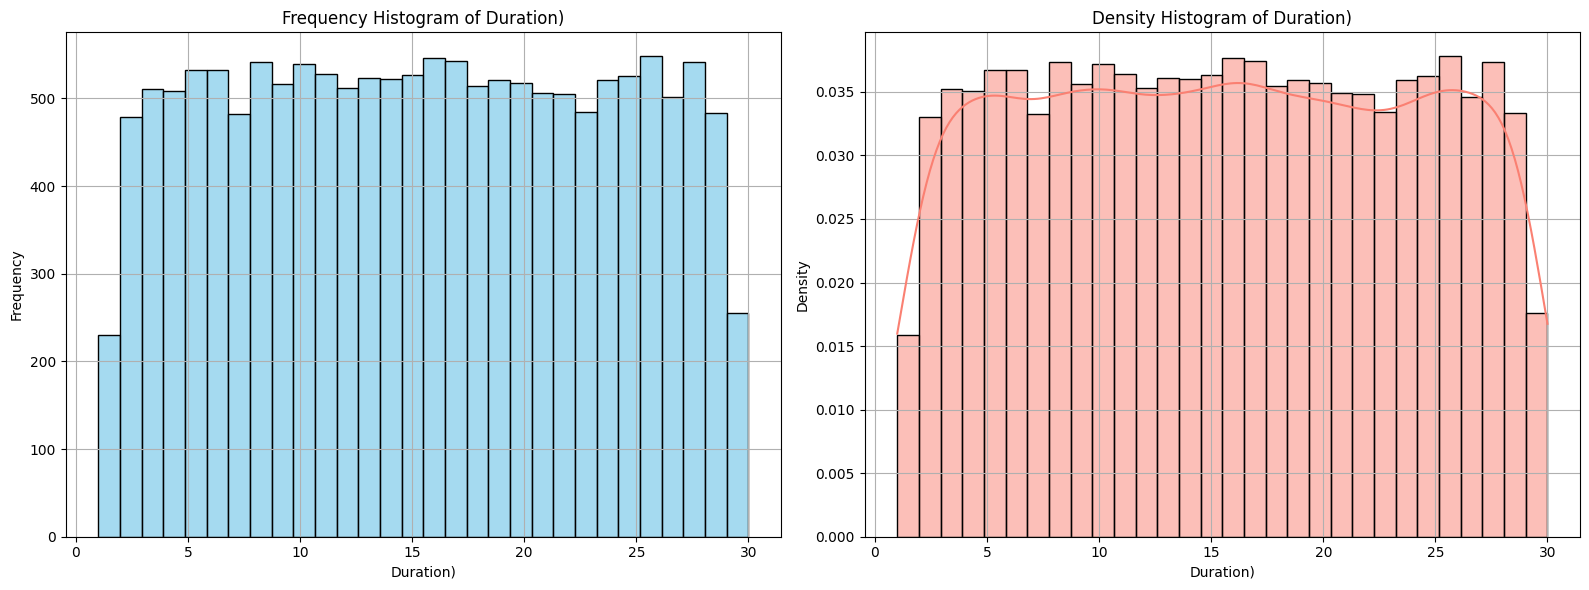

In [ ]:
# Set up subplots: 1 row, 2 columns
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Frequency histogram
sns.histplot(df['Duration'], bins=30, kde=False, color='skyblue', ax=axes[0])
axes[0].set_title("Frequency Histogram of Duration)")
axes[0].set_xlabel("Duration)")
axes[0].set_ylabel("Frequency")
axes[0].grid(True)

# Density histogram
sns.histplot(df['Duration'], bins=30, kde=True, stat="density", color='salmon', ax=axes[1])
axes[1].set_title("Density Histogram of Duration)")
axes[1].set_xlabel("Duration)")
axes[1].set_ylabel("Density")
axes[1].grid(True)

# Adjust layout
plt.tight_layout()
plt.show()

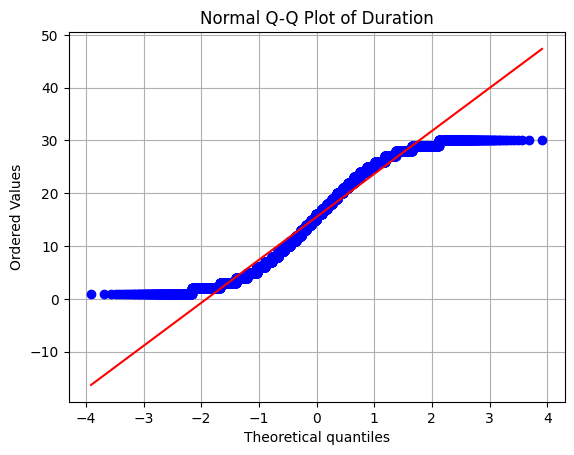

In [ ]:
stats.probplot(df['Duration'], dist="norm", plot=plt)
plt.title("Normal Q-Q Plot of Duration")
plt.grid(True)
plt.show()

**Linearity:We can check this by using scatterplot between Calories and Duration **

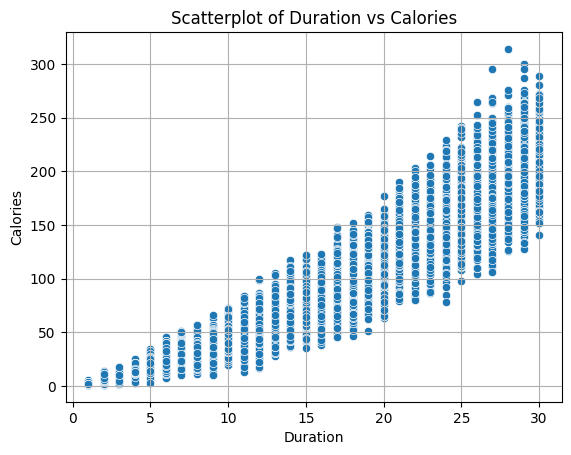

In [ ]:
sns.scatterplot(x='Duration', y='Calories', data=df)
plt.title("Scatterplot of Duration vs Calories")
plt.xlabel("Duration")
plt.ylabel("Calories")
plt.grid(True)
plt.show()

/tmp/ipython-input-136-740918140.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  height_bar = df.groupby('Duration_Group')['Calories'].mean().reset_index()
/tmp/ipython-input-136-740918140.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Duration_Group', y='Calories', data=height_bar, palette='viridis')


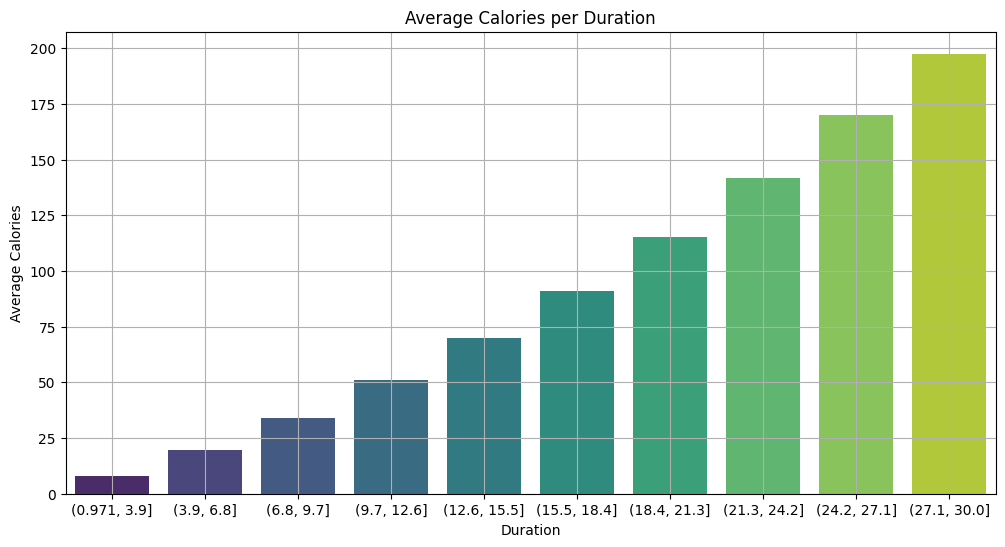

In [ ]:
# Bin height into groups
df['Duration_Group'] = pd.cut(df['Duration'], bins=10)

height_bar = df.groupby('Duration_Group')['Calories'].mean().reset_index()
avg_calories = df.groupby('Duration')['Calories'].mean().reset_index()

# Line plot
plt.figure(figsize=(12, 6))
sns.barplot(x='Duration_Group', y='Calories', data=height_bar, palette='viridis')

plt.title("Average Calories per Duration")
plt.xlabel("Duration")
plt.ylabel("Average Calories")
plt.grid(True)
plt.show()

**Fitting a linear model between Calories vs Duration**

Intercept: -21.859656399672318
Slope: 7.172883837907464
R² Score: 0.9128283957842549
RMSE: 18.4397066961982


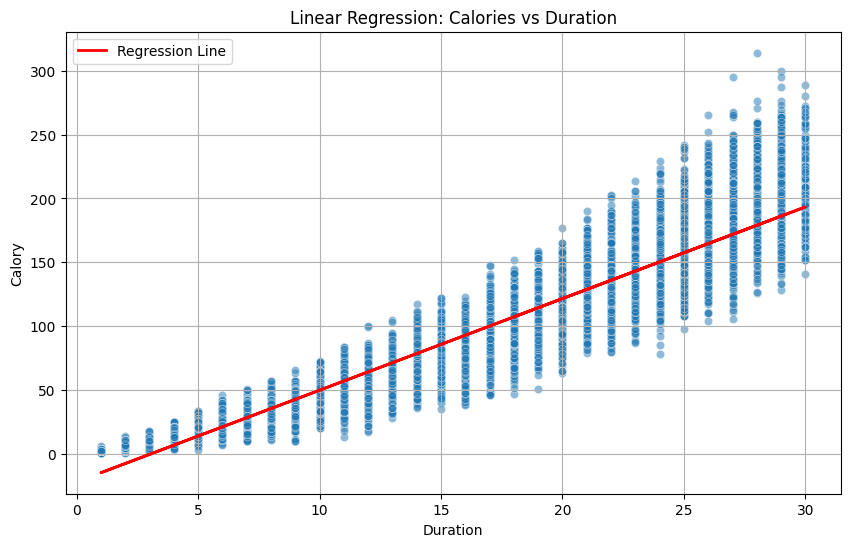

In [ ]:
# Reshape X for sklearn (expects 2D array)
X = df[['Duration']]     # independent variable
y = df['Calories']       # dependent variable
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

# Calculate R² and RMSE
r2 = r2_score(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))

print("Intercept:", model.intercept_)
print("Slope:", model.coef_[0])
print("R² Score:", r2)
print("RMSE:", rmse)

plt.figure(figsize=(10, 6))
sns.scatterplot(x='Duration', y='Calories', data=df, alpha=0.5)
plt.plot(df['Duration'], y_pred, color='red', linewidth=2, label='Regression Line')

plt.title("Linear Regression: Calories vs Duration")
plt.xlabel("Duration")
plt.ylabel("Calory")
plt.legend()
plt.grid(True)
plt.show()


*The linear regression model indicates a highly significant and strong relationship between
Duration and Calories. Specifically:*

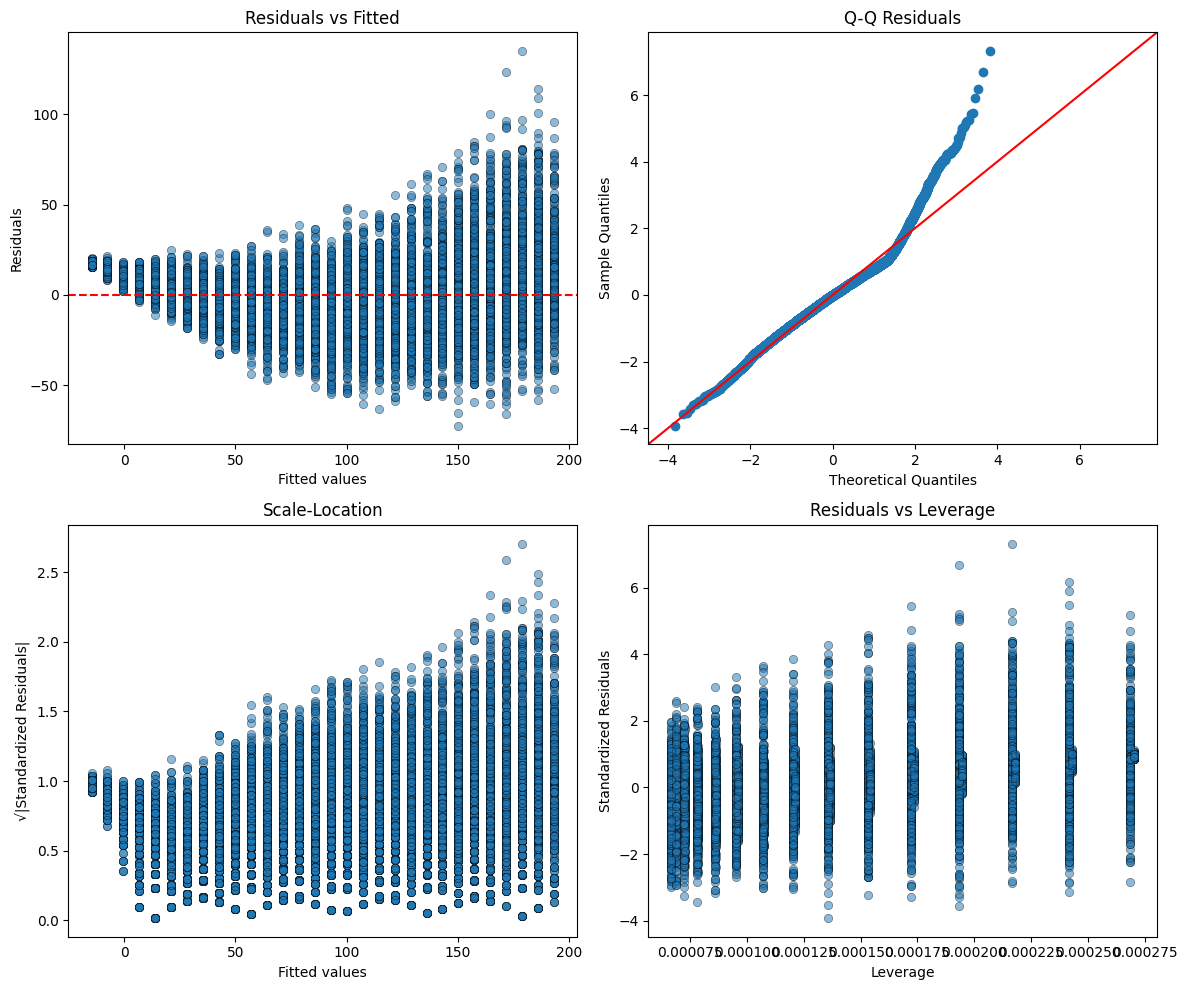

In [ ]:
# Prepare data
X = df['Duration']
y = df['Calories']
X_const = sm.add_constant(X)  # Adds intercept term

# Fit OLS model
model = sm.OLS(y, X_const).fit()

# Extract diagnostics
fitted_vals = model.fittedvalues
residuals = model.resid
standardized_resid = residuals / np.std(residuals)
sqrt_std_resid = np.sqrt(np.abs(standardized_resid))
influence = model.get_influence()
leverage = influence.hat_matrix_diag

# Set up 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. Residuals vs Fitted
sns.scatterplot(x=fitted_vals, y=residuals, ax=axes[0, 0], edgecolor='k', alpha=0.5)
axes[0, 0].axhline(0, ls='--', color='red')
axes[0, 0].set_title("Residuals vs Fitted")
axes[0, 0].set_xlabel("Fitted values")
axes[0, 0].set_ylabel("Residuals")

# 2. Q-Q Plot
sm.qqplot(standardized_resid, line='45', ax=axes[0, 1])
axes[0, 1].set_title("Q-Q Residuals")

# 3. Scale-Location
sns.scatterplot(x=fitted_vals, y=sqrt_std_resid, ax=axes[1, 0], edgecolor='k', alpha=0.5)
axes[1, 0].set_title("Scale-Location")
axes[1, 0].set_xlabel("Fitted values")
axes[1, 0].set_ylabel("√|Standardized Residuals|")

# 4. Residuals vs Leverage
sns.scatterplot(x=leverage, y=standardized_resid, ax=axes[1, 1], edgecolor='k', alpha=0.5)
axes[1, 1].set_title("Residuals vs Leverage")
axes[1, 1].set_xlabel("Leverage")
axes[1, 1].set_ylabel("Standardized Residuals")

# Layout adjustment
plt.tight_layout()
plt.show()

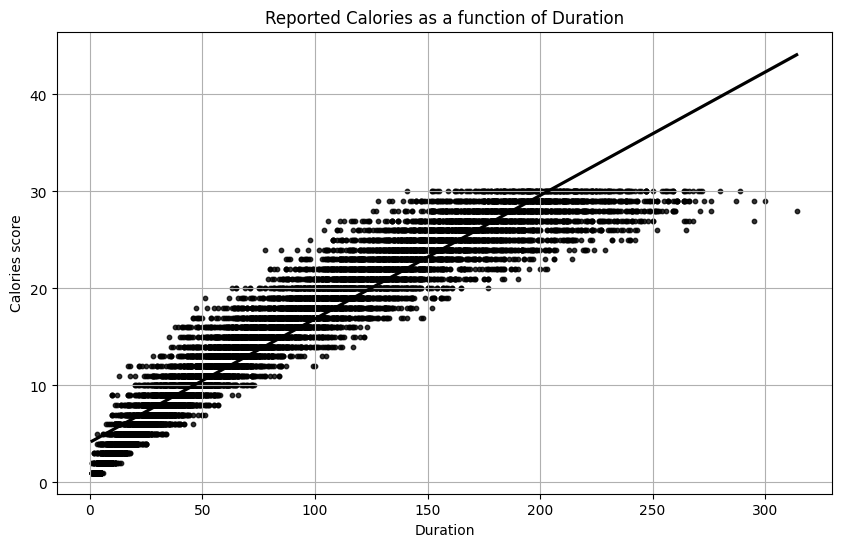

In [ ]:
# Replace with your actual column names if different
plt.figure(figsize=(10, 6))
sns.regplot(x='Calories', y='Duration', data=df, scatter_kws={'color': 'black', 's': 10}, line_kws={'color': 'black'})

# Customize the plot
plt.title("Reported Calories as a function of Duration")
plt.xlabel("Duration")
plt.ylabel("Calories score")
plt.grid(True)
plt.show()

# **Heart_Rate **

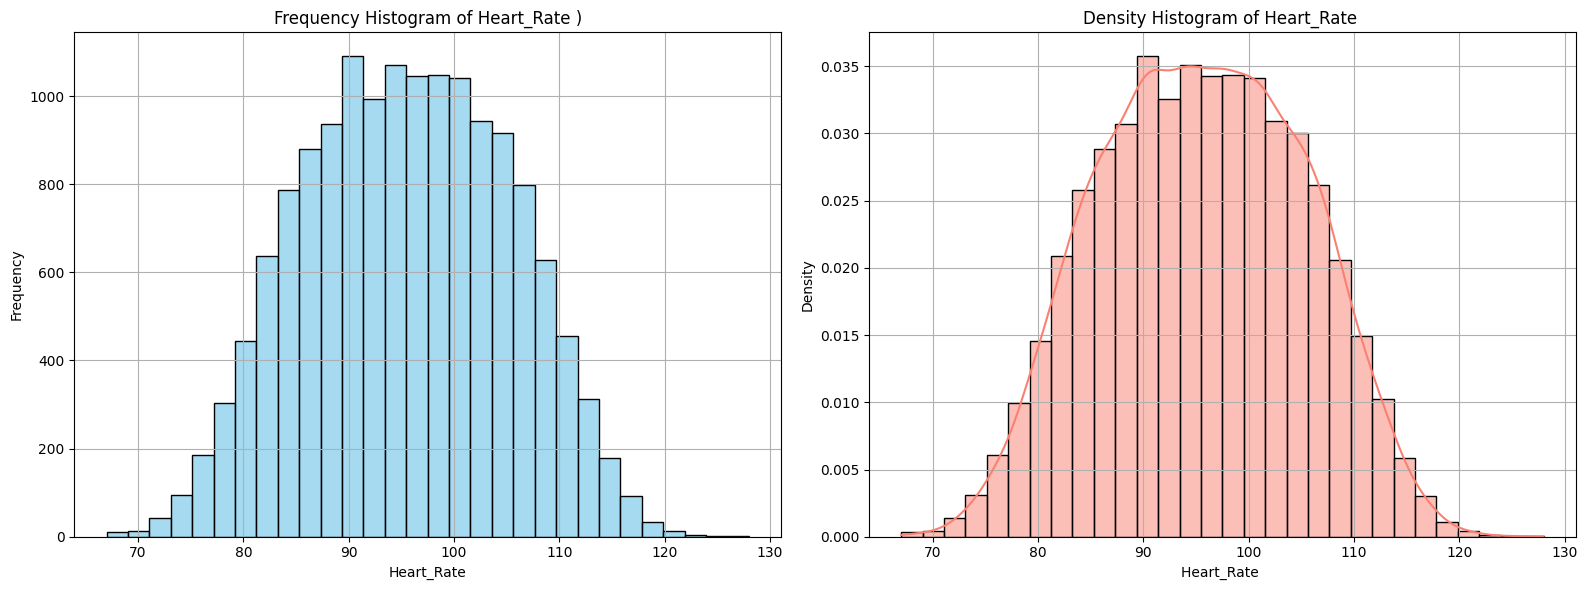

In [ ]:
# Set up subplots: 1 row, 2 columns
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Frequency histogram
sns.histplot(df['Heart_Rate'], bins=30, kde=False, color='skyblue', ax=axes[0])
axes[0].set_title("Frequency Histogram of Heart_Rate )")
axes[0].set_xlabel("Heart_Rate")
axes[0].set_ylabel("Frequency")
axes[0].grid(True)

# Density histogram
sns.histplot(df['Heart_Rate'], bins=30, kde=True, stat="density", color='salmon', ax=axes[1])
axes[1].set_title("Density Histogram of Heart_Rate ")
axes[1].set_xlabel("Heart_Rate ")
axes[1].set_ylabel("Density")
axes[1].grid(True)

# Adjust layout
plt.tight_layout()
plt.show()

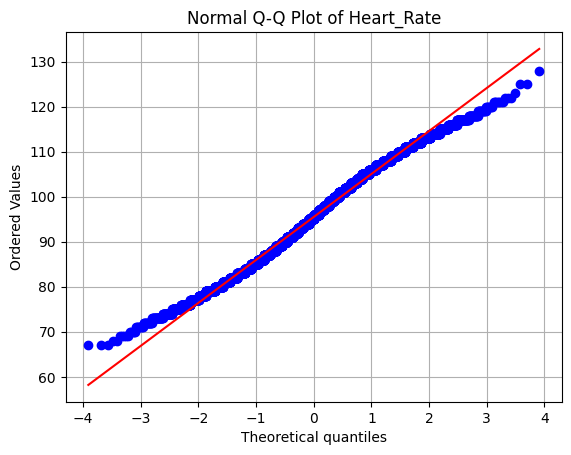

In [ ]:
stats.probplot(df['Heart_Rate'], dist="norm", plot=plt)
plt.title("Normal Q-Q Plot of Heart_Rate")
plt.grid(True)
plt.show()

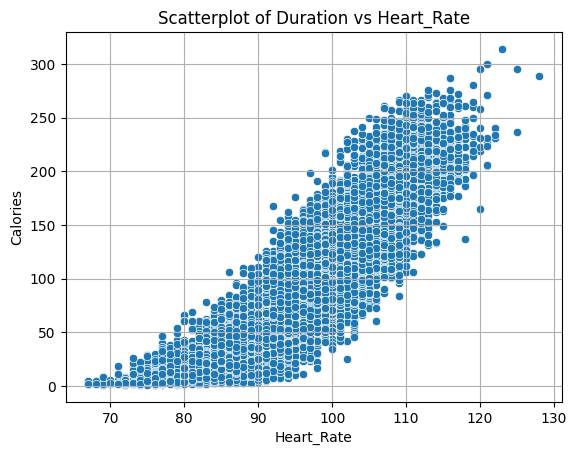

In [ ]:
sns.scatterplot(x='Heart_Rate', y='Calories', data=df)
plt.title("Scatterplot of Duration vs Heart_Rate")
plt.xlabel("Heart_Rate")
plt.ylabel("Calories")
plt.grid(True)
plt.show()

/tmp/ipython-input-143-2629587123.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  height_bar = df.groupby('Heart_Rate1')['Calories'].mean().reset_index()
/tmp/ipython-input-143-2629587123.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Heart_Rate1', y='Calories', data=height_bar, palette='viridis')


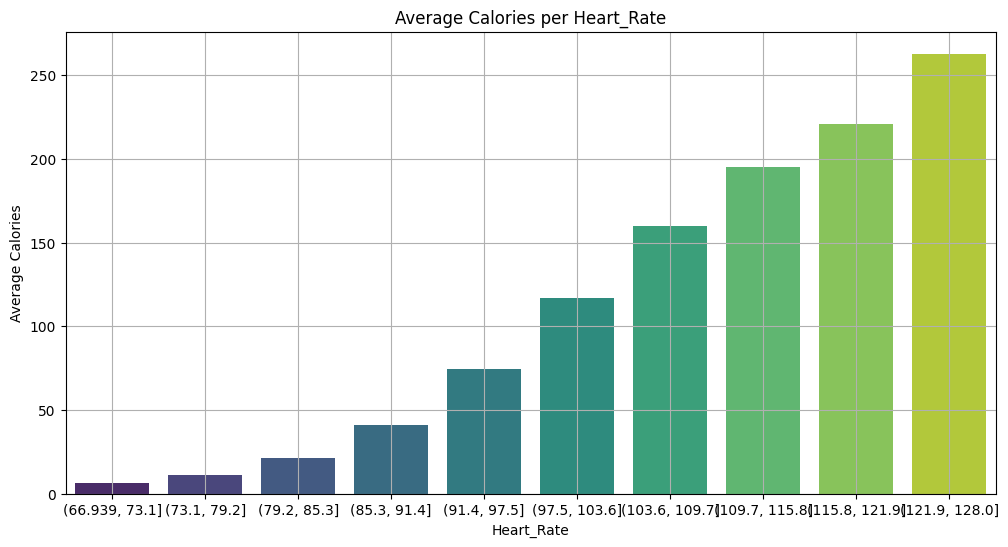

In [ ]:
# Bin height into groups
df['Heart_Rate1'] = pd.cut(df['Heart_Rate'], bins=10)

height_bar = df.groupby('Heart_Rate1')['Calories'].mean().reset_index()
avg_calories = df.groupby('Heart_Rate')['Calories'].mean().reset_index()

# Line plot
plt.figure(figsize=(12, 6))
sns.barplot(x='Heart_Rate1', y='Calories', data=height_bar, palette='viridis')

plt.title("Average Calories per Heart_Rate")
plt.xlabel("Heart_Rate")
plt.ylabel("Average Calories")
plt.grid(True)
plt.show()

Intercept: -469.40864533889237
Slope: 5.851724886956238
R² Score: 0.8061921948170285
RMSE: 27.494898534078196


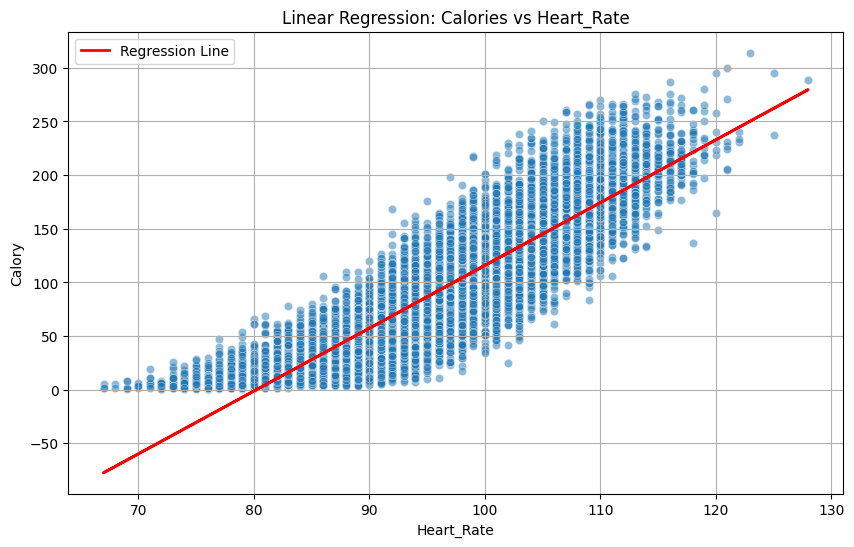

In [ ]:
# Reshape X for sklearn (expects 2D array)
X = df[['Heart_Rate']]     # independent variable
y = df['Calories']       # dependent variable
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

# Calculate R² and RMSE
r2 = r2_score(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))

print("Intercept:", model.intercept_)
print("Slope:", model.coef_[0])
print("R² Score:", r2)
print("RMSE:", rmse)

plt.figure(figsize=(10, 6))
sns.scatterplot(x='Heart_Rate', y='Calories', data=df, alpha=0.5)
plt.plot(df['Heart_Rate'], y_pred, color='red', linewidth=2, label='Regression Line')

plt.title("Linear Regression: Calories vs Heart_Rate")
plt.xlabel("Heart_Rate")
plt.ylabel("Calory")
plt.legend()
plt.grid(True)
plt.show()


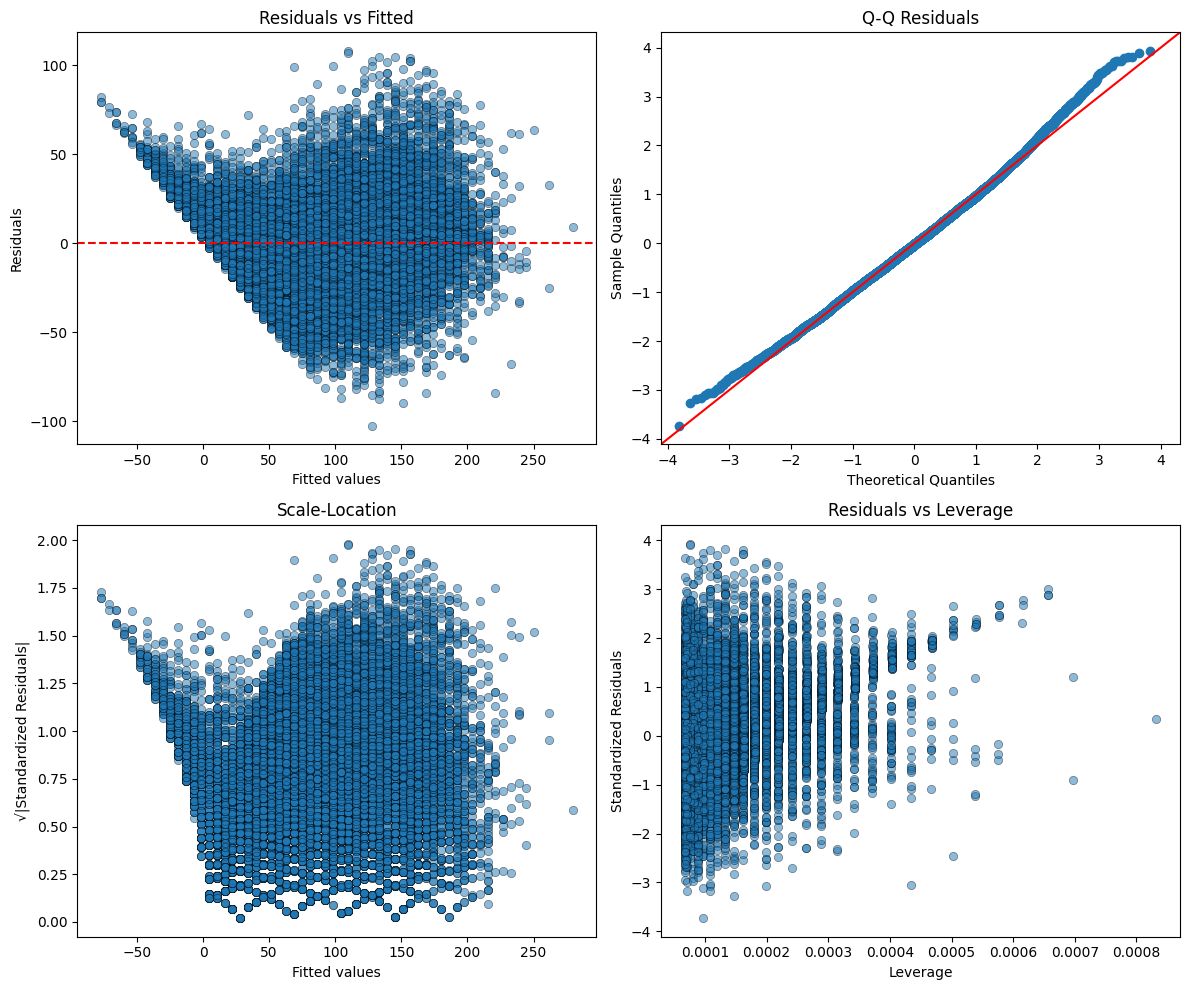

In [ ]:
# Prepare data
X = df['Heart_Rate']
y = df['Calories']
X_const = sm.add_constant(X)  # Adds intercept term

# Fit OLS model
model = sm.OLS(y, X_const).fit()

# Extract diagnostics
fitted_vals = model.fittedvalues
residuals = model.resid
standardized_resid = residuals / np.std(residuals)
sqrt_std_resid = np.sqrt(np.abs(standardized_resid))
influence = model.get_influence()
leverage = influence.hat_matrix_diag

# Set up 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. Residuals vs Fitted
sns.scatterplot(x=fitted_vals, y=residuals, ax=axes[0, 0], edgecolor='k', alpha=0.5)
axes[0, 0].axhline(0, ls='--', color='red')
axes[0, 0].set_title("Residuals vs Fitted")
axes[0, 0].set_xlabel("Fitted values")
axes[0, 0].set_ylabel("Residuals")

# 2. Q-Q Plot
sm.qqplot(standardized_resid, line='45', ax=axes[0, 1])
axes[0, 1].set_title("Q-Q Residuals")

# 3. Scale-Location
sns.scatterplot(x=fitted_vals, y=sqrt_std_resid, ax=axes[1, 0], edgecolor='k', alpha=0.5)
axes[1, 0].set_title("Scale-Location")
axes[1, 0].set_xlabel("Fitted values")
axes[1, 0].set_ylabel("√|Standardized Residuals|")

# 4. Residuals vs Leverage
sns.scatterplot(x=leverage, y=standardized_resid, ax=axes[1, 1], edgecolor='k', alpha=0.5)
axes[1, 1].set_title("Residuals vs Leverage")
axes[1, 1].set_xlabel("Leverage")
axes[1, 1].set_ylabel("Standardized Residuals")

# Layout adjustment
plt.tight_layout()
plt.show()

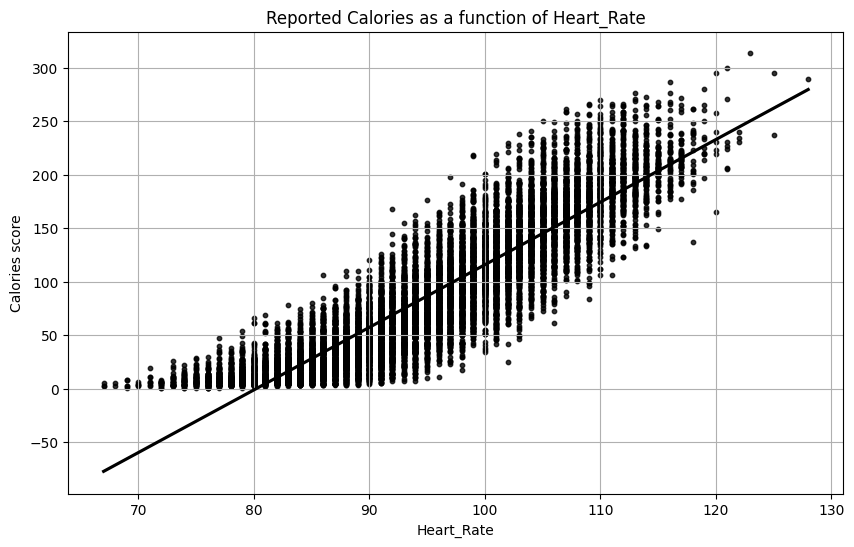

In [ ]:
# Replace with your actual column names if different
plt.figure(figsize=(10, 6))
sns.regplot(x='Heart_Rate', y='Calories', data=df, scatter_kws={'color': 'black', 's': 10}, line_kws={'color': 'black'})

# Customize the plot
plt.title("Reported Calories as a function of Heart_Rate")
plt.xlabel("Heart_Rate")
plt.ylabel("Calories score")
plt.grid(True)
plt.show()

# BODY TEMPERATURE

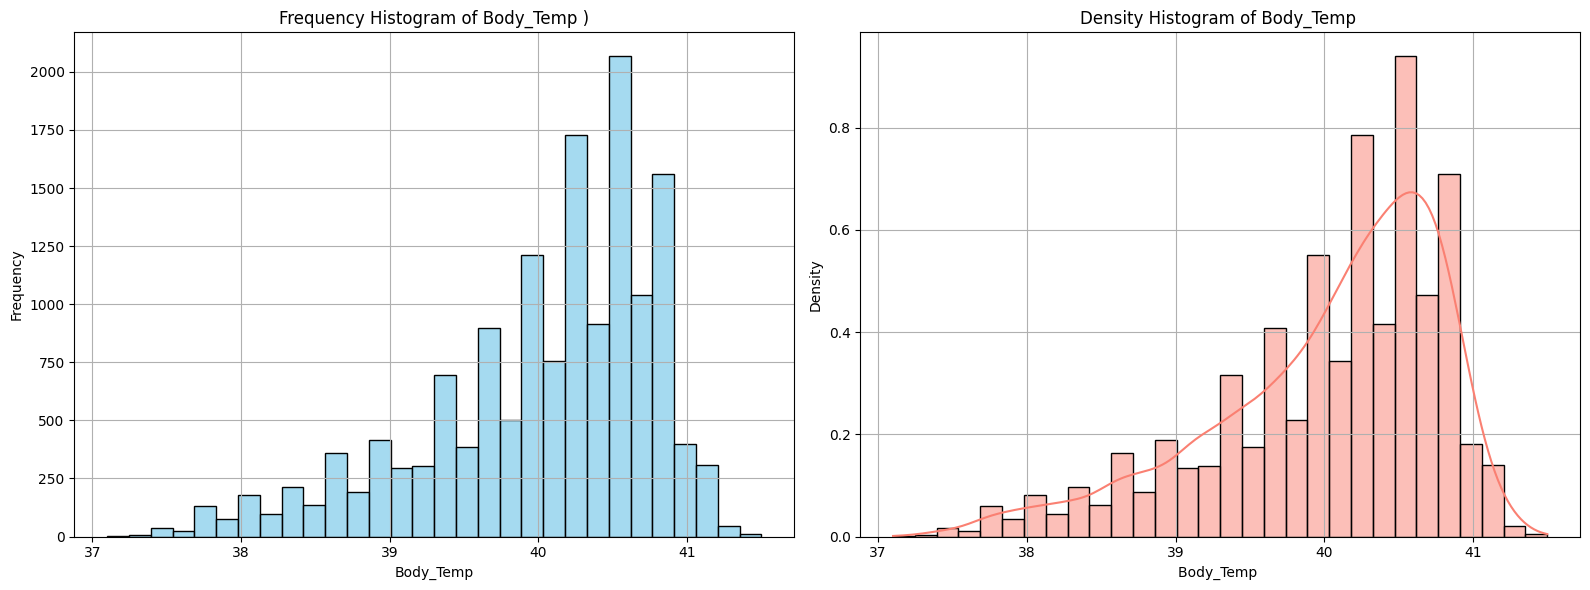

In [ ]:
# Set up subplots: 1 row, 2 columns
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Frequency histogram
sns.histplot(df['Body_Temp'], bins=30, kde=False, color='skyblue', ax=axes[0])
axes[0].set_title("Frequency Histogram of Body_Temp )")
axes[0].set_xlabel("Body_Temp")
axes[0].set_ylabel("Frequency")
axes[0].grid(True)

# Density histogram
sns.histplot(df['Body_Temp'], bins=30, kde=True, stat="density", color='salmon', ax=axes[1])
axes[1].set_title("Density Histogram of Body_Temp ")
axes[1].set_xlabel("Body_Temp ")
axes[1].set_ylabel("Density")
axes[1].grid(True)

# Adjust layout
plt.tight_layout()
plt.show()

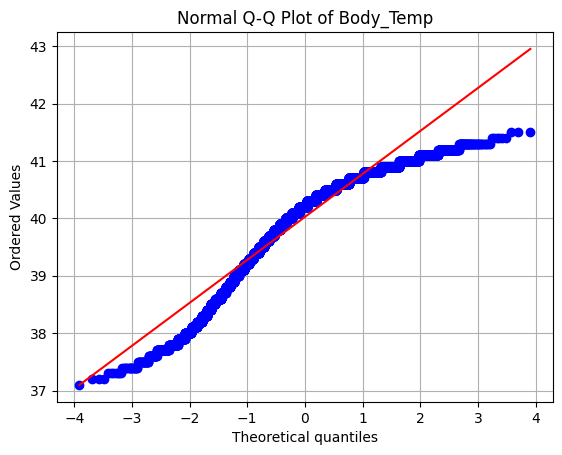

In [ ]:
stats.probplot(df['Body_Temp'], dist="norm", plot=plt)
plt.title("Normal Q-Q Plot of Body_Temp")
plt.grid(True)
plt.show()

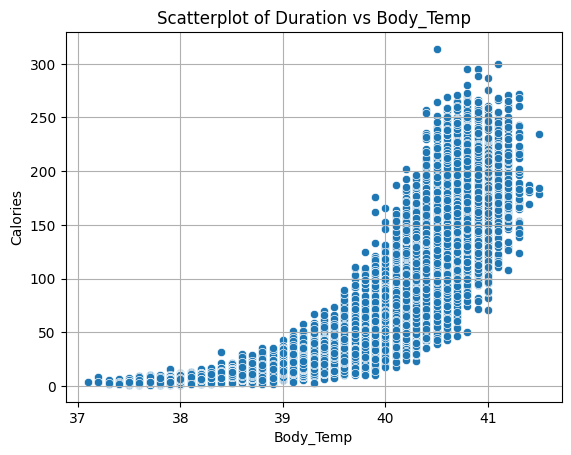

In [ ]:
sns.scatterplot(x='Body_Temp', y='Calories', data=df)
plt.title("Scatterplot of Duration vs Body_Temp")
plt.xlabel("Body_Temp")
plt.ylabel("Calories")
plt.grid(True)
plt.show()

/tmp/ipython-input-150-12186773.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  height_bar = df.groupby('Body_Temp1')['Calories'].mean().reset_index()
/tmp/ipython-input-150-12186773.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Body_Temp1', y='Calories', data=height_bar, palette='viridis')


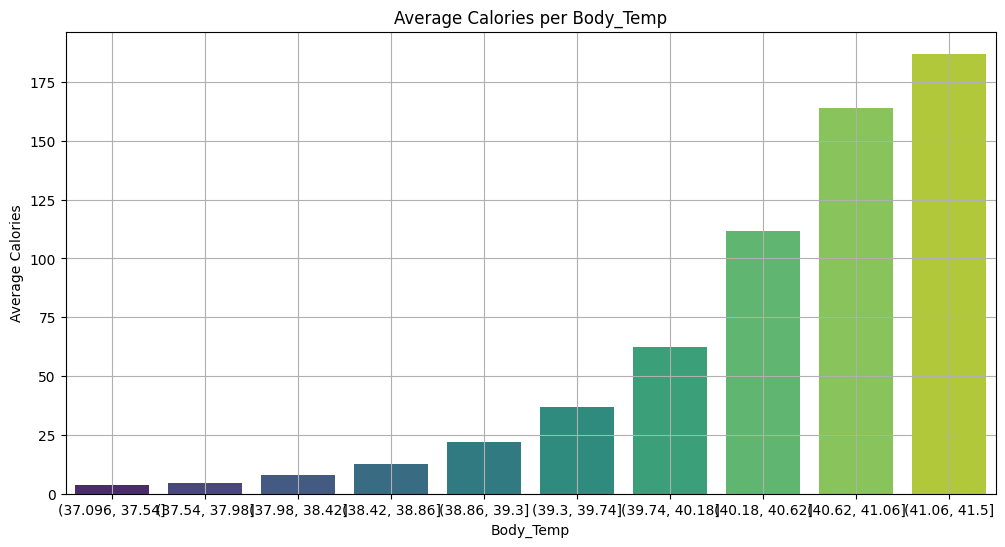

In [ ]:
# Bin height into groups
df['Body_Temp1'] = pd.cut(df['Body_Temp'], bins=10)

height_bar = df.groupby('Body_Temp1')['Calories'].mean().reset_index()
avg_calories = df.groupby('Body_Temp')['Calories'].mean().reset_index()

# Line plot
plt.figure(figsize=(12, 6))
sns.barplot(x='Body_Temp1', y='Calories', data=height_bar, palette='viridis')

plt.title("Average Calories per Body_Temp")
plt.xlabel("Body_Temp")
plt.ylabel("Average Calories")
plt.grid(True)
plt.show()

Intercept: -2555.7467877671534
Slope: 66.09010269216571
R² Score: 0.6798954958149548
RMSE: 35.33559285434592


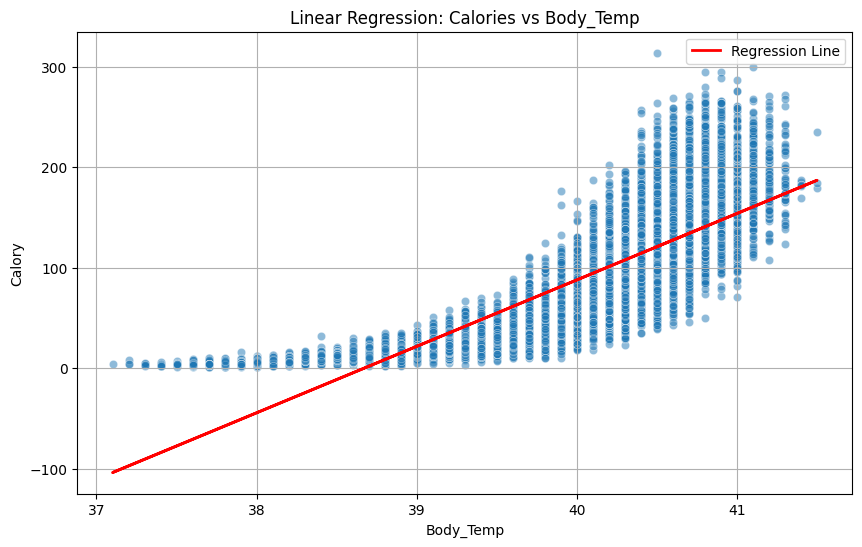

In [ ]:
# Reshape X for sklearn (expects 2D array)
X = df[['Body_Temp']]     # independent variable
y = df['Calories']       # dependent variable
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

# Calculate R² and RMSE
r2 = r2_score(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))

print("Intercept:", model.intercept_)
print("Slope:", model.coef_[0])
print("R² Score:", r2)
print("RMSE:", rmse)

plt.figure(figsize=(10, 6))
sns.scatterplot(x='Body_Temp', y='Calories', data=df, alpha=0.5)
plt.plot(df['Body_Temp'], y_pred, color='red', linewidth=2, label='Regression Line')

plt.title("Linear Regression: Calories vs Body_Temp")
plt.xlabel("Body_Temp")
plt.ylabel("Calory")
plt.legend()
plt.grid(True)
plt.show()


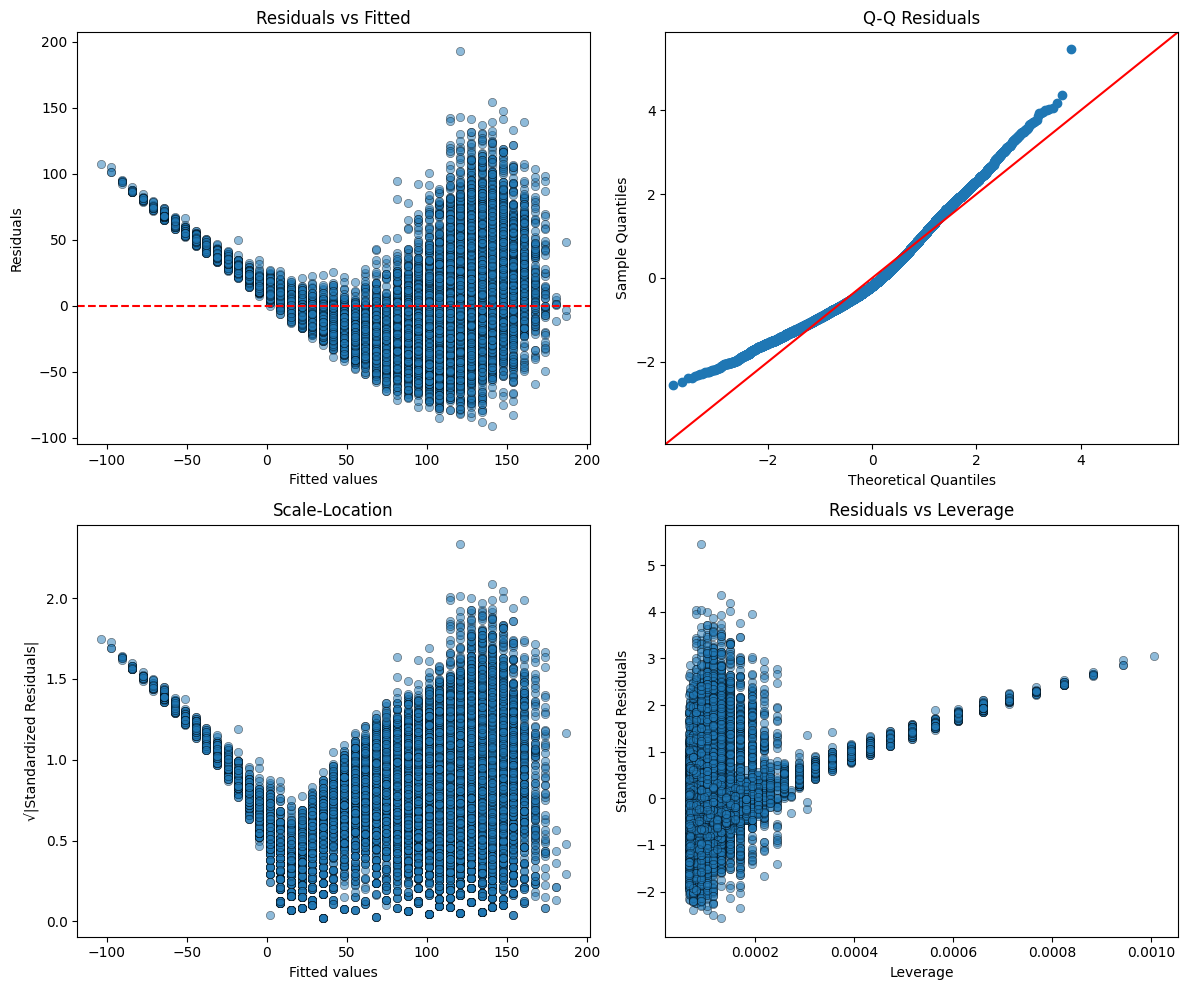

In [ ]:
# Prepare data
X = df['Body_Temp']
y = df['Calories']
X_const = sm.add_constant(X)  # Adds intercept term

# Fit OLS model
model = sm.OLS(y, X_const).fit()

# Extract diagnostics
fitted_vals = model.fittedvalues
residuals = model.resid
standardized_resid = residuals / np.std(residuals)
sqrt_std_resid = np.sqrt(np.abs(standardized_resid))
influence = model.get_influence()
leverage = influence.hat_matrix_diag

# Set up 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. Residuals vs Fitted
sns.scatterplot(x=fitted_vals, y=residuals, ax=axes[0, 0], edgecolor='k', alpha=0.5)
axes[0, 0].axhline(0, ls='--', color='red')
axes[0, 0].set_title("Residuals vs Fitted")
axes[0, 0].set_xlabel("Fitted values")
axes[0, 0].set_ylabel("Residuals")

# 2. Q-Q Plot
sm.qqplot(standardized_resid, line='45', ax=axes[0, 1])
axes[0, 1].set_title("Q-Q Residuals")

# 3. Scale-Location
sns.scatterplot(x=fitted_vals, y=sqrt_std_resid, ax=axes[1, 0], edgecolor='k', alpha=0.5)
axes[1, 0].set_title("Scale-Location")
axes[1, 0].set_xlabel("Fitted values")
axes[1, 0].set_ylabel("√|Standardized Residuals|")

# 4. Residuals vs Leverage
sns.scatterplot(x=leverage, y=standardized_resid, ax=axes[1, 1], edgecolor='k', alpha=0.5)
axes[1, 1].set_title("Residuals vs Leverage")
axes[1, 1].set_xlabel("Leverage")
axes[1, 1].set_ylabel("Standardized Residuals")

# Layout adjustment
plt.tight_layout()
plt.show()

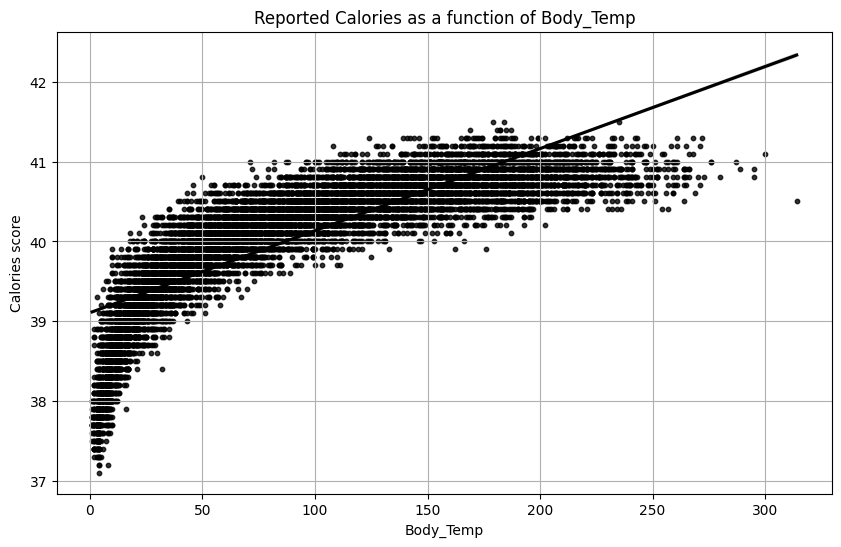

In [ ]:
# Replace with your actual column names if different
plt.figure(figsize=(10, 6))
sns.regplot(x='Calories', y='Body_Temp', data=df, scatter_kws={'color': 'black', 's': 10}, line_kws={'color': 'black'})

# Customize the plot
plt.title("Reported Calories as a function of Body_Temp")
plt.xlabel("Body_Temp")
plt.ylabel("Calories score")
plt.grid(True)
plt.show()